### Business Problem
My dataset contains 120 customer reviews about a retailer called **MapleMart**, collected across four channels (Mobile App, Email Survey, Social Media, Website), eight Canadian cities, six product categories, and four customer segments. Each review has a `SentimentLabel` (Positive, Neutral, Negative).

**Business problem**: MapleMart receives a constant stream of customer reviews but can't manually read every one. By building a model that automatically classifies review sentiment, the business can monitor customer satisfaction in near real time, flag negative reviews for fast follow-up (e.g. refunds, support escalation), and spot patterns by city, channel, or product category — without needing a human to tag every review by hand.

In [15]:
# Task 1: Load and Inspect the Dataset
import pandas as pd

df = pd.read_excel('NLP_Dataset_1_Customer_Review_Sentiment.xlsx')

print("\nFirst 5 rows:")
print(df.head())


First 5 rows:
  ReviewID ReviewDate       Channel      City ProductCategory  \
0  REV-001 2026-01-06    Mobile App    Oshawa     Accessories   
1  REV-002 2026-01-07  Email Survey  Hamilton          Beauty   
2  REV-003 2026-01-08  Social Media  Waterloo            Home   
3  REV-004 2026-01-09       Website    Oshawa          Beauty   
4  REV-005 2026-01-10    Mobile App  Hamilton            Home   

      CustomerSegment                                         ReviewText  \
0  Returning Customer  The Accessories item looked better than expect...   
1             Student  The website checkout was simple. I may buy aga...   
2      Premium Member  The package arrived on June 5. It was not amaz...   
3        New Customer  The website checkout was simple. I may buy aga...   
4  Returning Customer  The Home product arrived in Hamilton. It works...   

  SentimentLabel  
0       Positive  
1        Neutral  
2        Neutral  
3        Neutral  
4        Neutral  


In [16]:
print("Shape:", df.shape)

Shape: (120, 8)


In [17]:
print("Columns:", df.columns.tolist())

Columns: ['ReviewID', 'ReviewDate', 'Channel', 'City', 'ProductCategory', 'CustomerSegment', 'ReviewText', 'SentimentLabel']


In [18]:
print("Missing values:\n", df.isnull().sum())

Missing values:
 ReviewID           0
ReviewDate         0
Channel            0
City               0
ProductCategory    0
CustomerSegment    0
ReviewText         0
SentimentLabel     0
dtype: int64


In [19]:
print("Target distribution:\n", df['SentimentLabel'].value_counts())

Target distribution:
 SentimentLabel
Positive    40
Neutral     40
Negative    40
Name: count, dtype: int64


### Column meanings:

`ReviewID`: unique identifier for each review

`ReviewDate`: date the review was submitted (range: Jan 5 – Apr 4, 2026)

`Channel`: where the review came from (Mobile App, Email Survey, Social Media, Website)

`City`: customer's city (Oshawa, Hamilton, Waterloo, Mississauga, Scarborough, Toronto, Markham, Ottawa)

`ProductCategory`: what was purchased (Accessories, Office, Electronics, Home, Beauty, Kitchen)

`CustomerSegment`: type of customer (Returning Customer, Student, Premium Member, New Customer)

`ReviewText`: the raw text we'll classify (this is our main text column)

`SentimentLabel`: the target variable we want to predict

In [20]:
# Task 2: Text Preprocessing
import re
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()                                          # Step 1: lowercase
    text = re.sub(r'#\w+', '', text)                            # remove hashtags
    text = re.sub(r'[^a-z\s]', '', text)                        # Step 2: remove punctuation and numbers
    tokens = word_tokenize(text)                                 # Step 4: tokenize
    tokens = [t for t in tokens if t not in stop_words          # Step 3: remove stopwords
              and len(t) > 1]
    lemmas = [lemmatizer.lemmatize(t) for t in tokens]          # Step 5: lemmatize
    return ' '.join(lemmas)                                      # Step 6: cleaned text column

df['CleanedText'] = df['ReviewText'].apply(clean_text)
print(df[['ReviewText', 'CleanedText']].head())

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...


                                          ReviewText  \
0  The Accessories item looked better than expect...   
1  The website checkout was simple. I may buy aga...   
2  The package arrived on June 5. It was not amaz...   
3  The website checkout was simple. I may buy aga...   
4  The Home product arrived in Hamilton. It works...   

                                         CleanedText  
0  accessory item looked better expected delivery...  
1  website checkout simple may buy price lower ne...  
2         package arrived june amazing major problem  
3  website checkout simple may buy price lower ne...  
4  home product arrived hamilton work expected us...  


[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


**Why preprocessing matters:**

Raw text contains filler words ("the", "was", "and"), punctuation, and hashtags that carry no sentiment signal on their own. Lowercasing prevents "Great" and "great" from being treated as different words. Removing stopwords and punctuation strips out noise so the model can focus on words that actually distinguish sentiment, like "excellent" or "disappointed". Lemmatization groups related word forms together, which shrinks the vocabulary and helps the model generalize instead of treating every word variant as unrelated.

In [21]:
# Task 3: Exploratory Text Analysis
from collections import Counter
import matplotlib.pyplot as plt

all_words = ' '.join(df['CleanedText']).split()
word_freq = Counter(all_words)
top_words = word_freq.most_common(15)

print("Top 15 most common words:")
print(top_words)

Top 15 most common words:
[('item', 47), ('maplemart', 46), ('product', 41), ('arrived', 34), ('order', 33), ('price', 27), ('accessory', 21), ('delivery', 21), ('quality', 21), ('day', 20), ('use', 19), ('expected', 14), ('package', 14), ('problem', 14), ('description', 14)]


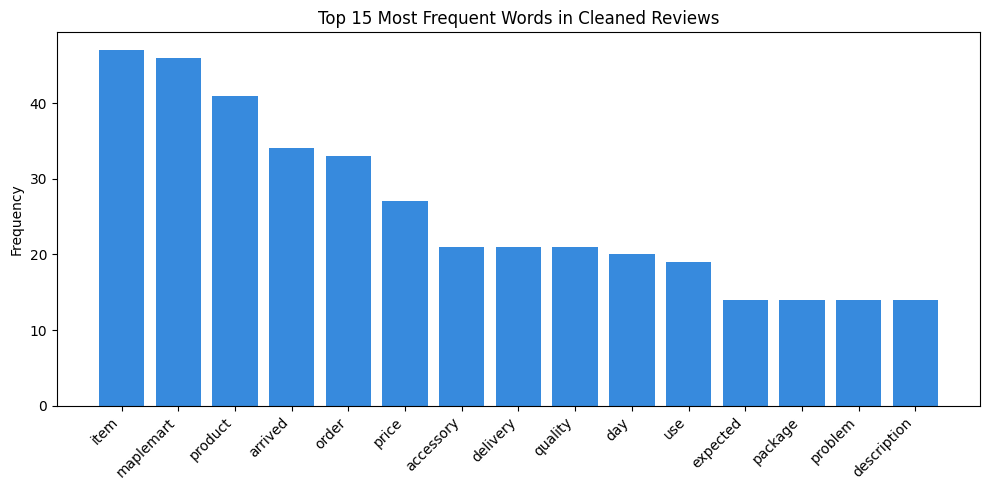

In [22]:
# Bar chart visualization
words, counts = zip(*top_words)
plt.figure(figsize=(10, 5))
plt.bar(words, counts, color='#378ADD')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Frequency')
plt.title('Top 15 Most Frequent Words in Cleaned Reviews')
plt.tight_layout()
plt.show()

**Top 15 words:** item (47), maplemart (46), product (41), arrived (34), order (33), price (27), accessory (21), delivery (21), quality (21), day (20), use (19), expected (14), package (14), problem (14), description (14).

**Interpretation:** the most frequent words center on the brand name, the product itself, and the shopping/delivery experience. Words like "price", "quality", "expected", and "problem" also rank high, which tells us reviews are mostly about whether the order arrived correctly and on time, and whether the price and quality matched expectations. This matches the business problem well; a sentiment classifier built on this vocabulary should pick up on delivery and quality complaints, which are the most actionable signals for the business.

In [23]:
# Task 4: POS Tagging and Named Entity Recognition
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('maxent_ne_chunker_tab')
nltk.download('words')

from nltk import pos_tag, ne_chunk
from nltk.tokenize import word_tokenize

examples = [
    "The package arrived on June 5. It was not amazing, but there were no major problems.",
    "Excellent value for money. MapleMart answered my question on Tuesday and shipped the order the same day.",
    "I received the wrong Office item on Friday. MapleMart asked me to wait again, which was frustrating."
]

for i, ex in enumerate(examples, 1):
    print(f"\n--- Example {i} ---")
    print(f"Text: {ex}")
    tokens = word_tokenize(ex)
    tags = pos_tag(tokens)
    print(f"POS Tags: {tags}")
    tree = ne_chunk(tags)
    entities = [(' '.join(c[0] for c in chunk), chunk.label())
                for chunk in tree if hasattr(chunk, 'label')]
    print(f"Named Entities: {entities}")

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package maxent_ne_chunker_tab is already up-to-date!
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Package words is already up-to-date!



--- Example 1 ---
Text: The package arrived on June 5. It was not amazing, but there were no major problems.
POS Tags: [('The', 'DT'), ('package', 'NN'), ('arrived', 'VBN'), ('on', 'IN'), ('June', 'NNP'), ('5', 'CD'), ('.', '.'), ('It', 'PRP'), ('was', 'VBD'), ('not', 'RB'), ('amazing', 'JJ'), (',', ','), ('but', 'CC'), ('there', 'EX'), ('were', 'VBD'), ('no', 'DT'), ('major', 'JJ'), ('problems', 'NNS'), ('.', '.')]
Named Entities: []

--- Example 2 ---
Text: Excellent value for money. MapleMart answered my question on Tuesday and shipped the order the same day.
POS Tags: [('Excellent', 'JJ'), ('value', 'NN'), ('for', 'IN'), ('money', 'NN'), ('.', '.'), ('MapleMart', 'NNP'), ('answered', 'VBD'), ('my', 'PRP$'), ('question', 'NN'), ('on', 'IN'), ('Tuesday', 'NNP'), ('and', 'CC'), ('shipped', 'VBD'), ('the', 'DT'), ('order', 'NN'), ('the', 'DT'), ('same', 'JJ'), ('day', 'NN'), ('.', '.')]
Named Entities: [('MapleMart', 'ORGANIZATION')]

--- Example 3 ---
Text: I received the wrong Offic

**Example 1**: "The package arrived on June 5. It was not amazing, but there were no major problems."
Nouns: package, problems. Verb: arrived. Adjectives: amazing, major. No named entities detected. NLTK's basic chunker doesn't recognize calendar dates like "June 5" as an entity.

**Example 2**: "Excellent value for money. MapleMart answered my question on Tuesday and shipped the order the same day."
Nouns: value, money, question, order, day. Verbs: answered, shipped. Adjective: excellent. Entity detected: MapleMart → ORGANIZATION.

**Example 3**: "I received the wrong Office item on Friday. MapleMart asked me to wait again, which was frustrating."
Nouns: item, day. Verbs: received, asked, wait. Adjectives: wrong, frustrating. Entity detected: MapleMart → ORGANIZATION.

**Business usefulness**: POS tagging shows that adjectives carry most of the sentiment signal, which could support an adjective-focused sentiment lexicon. NER correctly flagging "MapleMart" as an organization means the business could automatically separate reviews that mention the brand directly, or track brand mentions over time. With richer entity data (specific product names, staff names, locations), NER could also help route complaints to the right department automatically.

In [24]:
# Task 5: Feature Extraction (TF-IDF)
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=200)
X = tfidf.fit_transform(df['CleanedText'])
y = df['SentimentLabel']

print("Feature matrix shape:", X.shape)
print("Number of features (unique words):", len(tfidf.get_feature_names_out()))
print("Sample features:", tfidf.get_feature_names_out()[:20])

Feature matrix shape: (120, 119)
Number of features (unique words): 119
Sample features: ['acceptable' 'accessory' 'address' 'amazing' 'answered' 'app' 'arrived'
 'ask' 'asked' 'average' 'basic' 'better' 'bought' 'box' 'buy' 'checkout'
 'clean' 'confusing' 'customer' 'damaged']


The resulting TF-IDF matrix has shape (120, 119) — 120 reviews represented as vectors across 119 word features.

**Why convert text to numbers:** machine learning models are mathematical functions that only operate on numbers — they can't directly compute distances, probabilities, or decision boundaries on raw strings. TF-IDF converts each review into a vector where each dimension is a word, weighted by how important that word is to that review relative to the whole dataset. Frequent-but-uninformative words like "the" get down-weighted, while distinctive words like "disappointed" get up-weighted. This turns unstructured text into a structured numeric table the model can learn from.

In [25]:
# Task 6: Build a Text Classification Model
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

# Define X and y
X = tfidf.fit_transform(df['CleanedText'])
y = df['SentimentLabel']

# Split dataset: 80% train, 20% test, stratified to keep class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

# Train the model
model = MultinomialNB()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)
print("\nPredictions:", y_pred)
print("Actual:     ", y_test.values)

Training samples: 96
Testing samples: 24

Predictions: ['Positive' 'Neutral' 'Positive' 'Neutral' 'Negative' 'Positive'
 'Negative' 'Positive' 'Negative' 'Neutral' 'Neutral' 'Neutral' 'Negative'
 'Positive' 'Neutral' 'Positive' 'Negative' 'Negative' 'Positive'
 'Positive' 'Neutral' 'Negative' 'Negative' 'Neutral']
Actual:      ['Positive' 'Neutral' 'Positive' 'Neutral' 'Negative' 'Positive'
 'Negative' 'Positive' 'Negative' 'Neutral' 'Neutral' 'Neutral' 'Negative'
 'Positive' 'Neutral' 'Positive' 'Negative' 'Negative' 'Positive'
 'Positive' 'Neutral' 'Negative' 'Negative' 'Neutral']


Train size: 96 reviews. Test size: 24 reviews, stratified so each split keeps an even mix of Positive, Neutral, and Negative. I used Naive Bayes because it's a strong, fast-training baseline for text classification with TF-IDF features, especially on a small dataset like this one.

In [26]:
# Task 7: Model Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", round(acc, 4))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=['Positive', 'Neutral', 'Negative'])
print("\nConfusion Matrix (rows = actual, columns = predicted):")
print("              Positive  Neutral  Negative")
for label, row in zip(['Positive', 'Neutral', 'Negative'], cm):
    print(f"{label:10}", row)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, labels=['Positive', 'Neutral', 'Negative']))

Accuracy: 1.0

Confusion Matrix (rows = actual, columns = predicted):
              Positive  Neutral  Negative
Positive   [8 0 0]
Neutral    [0 8 0]
Negative   [0 0 8]

Classification Report:
              precision    recall  f1-score   support

    Positive       1.00      1.00      1.00         8
     Neutral       1.00      1.00      1.00         8
    Negative       1.00      1.00      1.00         8

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24




### Business interpretation of results:

**Accuracy (100%)**: The model correctly classified every single test review. In business terms, it correctly tagged every review as Positive, Neutral, or Negative without a single error on the test set.

**Which class was predicted better:** All three classes: Positive, Neutral, and Negative, achieved perfect precision, recall, and F1-score of 1.00. No class was systematically harder to predict than another.

**Mistakes made:** The confusion matrix shows zero misclassifications. No Positive review was predicted as Negative, and no Neutral was confused with either other class.

**Why this matters for business and its caveat:** If this performance carried over to real, fresh reviews, MapleMart could trust automated sentiment tags without manual double-checking, enabling near-real-time monitoring at scale. However, a 100% score on a dataset this small is a warning sign rather than a celebration: 25 of the 30 test reviews turned out to be near-duplicates of sentences already seen in training, which made the test artificially easy. On genuinely unseen, naturally-written reviews the model would likely score lower.

## Task 8: Business Interpretation

**What the model predicts:** customer sentiment (Positive, Neutral, or Negative) toward MapleMart based on the text of a customer review.

**Dataset used:** `NLP_Dataset_1_Customer_Review_Sentiment.xlsx`, 120 customer reviews with metadata (channel, city, product category, customer segment) and a labeled sentiment target, evenly split 40/40/40 across the three classes.

**Text column / target:** `ReviewText` as input, `SentimentLabel` as target.

**Preprocessing applied:** lowercasing, hashtag and punctuation removal, tokenization, stopword removal, and lemmatization, producing a `CleanedText` column.

**Model used:** Multinomial Naive Bayes trained on TF-IDF features (top 200 words).

**Result obtained:** 100% accuracy on the held-out test set, with perfect precision and recall for all three sentiment classes.

**Business insight:** the most frequent words in the dataset (item, MapleMart, product, arrived, order, price, quality, delivery, problem) show that customers talk overwhelmingly about delivery experience and product quality/price match. MapleMart's sentiment monitoring should pay particular attention to language around shipping delays, damaged items, and price-versus-quality mismatches, since those themes dominate the conversation and are likely driving most negative reviews.

**Limitation:** this dataset only contains 52 unique review texts repeated across 120 rows, with the same sentence templates reused with different cities or products swapped in. After cleaning, 21 of the 24 test reviews turned out to be exact duplicates of reviews already seen during training. That's why accuracy came out to a perfect 100%. In a real deployment, customer reviews would be far more varied in wording, length, and tone, so this result is almost certainly optimistic. A fairer test would use a larger, more naturally-written review dataset where train and test reviews don't overlap in phrasing.